# Machine Learning Wrapup - Classification - SLB - Davy WAI

* ✅ Friday, June 19, 2026 - Morning - `Workflow` = `Pipeline` and `ColumnTransformer`
* ▶️ Monday, June 22, 2026 - `SVC` and `Optimizing hyper parameters`
* 🔴 Tuesday, June 23, 2026 - `Ensemble Methods`, `State-of-the-art models`

## Libraries

In [1]:
# DATA MANIPULATION
import pandas as pd
pd.set_option("display.max_columns", None)
import numpy as np
import datetime

# STATS
from statsmodels.graphics.gofplots import qqplot

# DATA VISUALISATION
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# ML
## PREPROC
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder

from sklearn.pipeline import Pipeline, make_pipeline # NEW
from sklearn.compose import ColumnTransformer, make_column_selector # NEW
## METRICS
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
## SUPERVISED MODEL
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
## TUNING
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

## Airline Customer Satisfaction (Classification)

### Dataset

#### Loading

❓ Load the dataset `airline_satifaction` from this [AWS URL](https://wagon-public-datasets.s3.amazonaws.com/data-science-images/05-ML/Reboot-2/Invistico_Airline.csv)

In [2]:
airline_satisfaction_url = "https://wagon-public-datasets.s3.amazonaws.com/data-science-images/05-ML/Reboot-2/Invistico_Airline.csv"
airline_satisfaction_url

'https://wagon-public-datasets.s3.amazonaws.com/data-science-images/05-ML/Reboot-2/Invistico_Airline.csv'

In [3]:
# LOAD IT INTO A DF VARIABLE
df = pd.read_csv(airline_satisfaction_url)
df.head()

,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,2,4,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,0,2,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,2,0,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,3,4,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,4,3,4,2,2,0,2,4,2,5,0,0.0


#### Basic info

❓ Look at some basic info (number of rows, number of columns), types of columns, ...

In [4]:
df.shape

(129880, 23)

#### Pre-cleaning

##### Duplicated

❓ Check the number of duplicated rows and remove them if need be.

In [5]:
df.duplicated()

# False = 0 = row is unique
# True = 1 = row is a duplicated version of a previous

0         False
1         False
2         False
3         False
4         False
          ...  
129875    False
129876    False
129877    False
129878    False
129879    False
Length: 129880, dtype: bool

In [6]:
# Number of duplicated rows
nb_duplicated_rows = df.duplicated().sum()
nb_duplicated_rows

0

In [7]:
# Removing duplicated rows
df.drop_duplicates(inplace=True)

#### What kind of data?

❓ Check the number of numerical columns and categorical columns.

In [8]:
# DATA TYPES
df.dtypes

satisfaction                          object
Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Seat comfort                           int64
Departure/Arrival time convenient      int64
Food and drink                         int64
Gate location                          int64
Inflight wifi service                  int64
Inflight entertainment                 int64
Online support                         int64
Ease of Online booking                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Cleanliness                            int64
Online boarding                        int64
Departure Delay in Minutes             int64
Arrival De

In [9]:
df.dtypes.value_counts()

int64      17
object      5
float64     1
Name: count, dtype: int64

<Axes: >

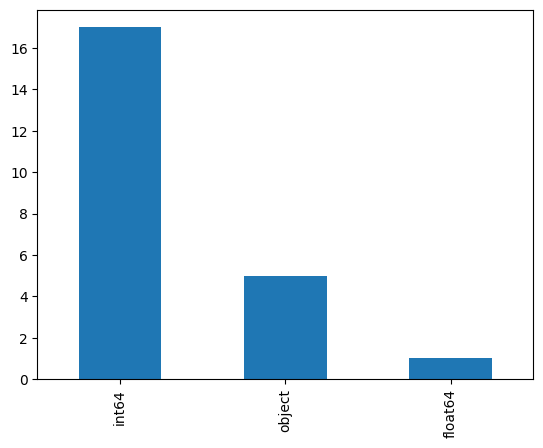

In [10]:
df.dtypes.value_counts().plot(kind="bar")

<Axes: ylabel='count'>

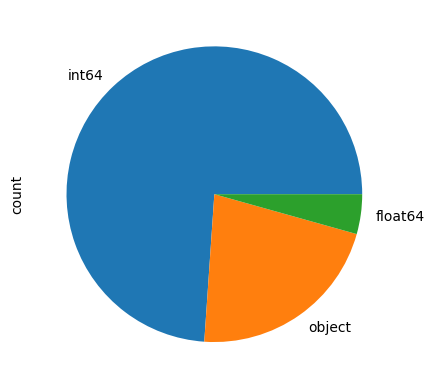

In [11]:
df.dtypes.value_counts().plot(kind="pie")

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Gender                             129880 non-null  object 
 2   Customer Type                      129880 non-null  object 
 3   Age                                129880 non-null  int64  
 4   Type of Travel                     129880 non-null  object 
 5   Class                              129880 non-null  object 
 6   Flight Distance                    129880 non-null  int64  
 7   Seat comfort                       129880 non-null  int64  
 8   Departure/Arrival time convenient  129880 non-null  int64  
 9   Food and drink                     129880 non-null  int64  
 10  Gate location                      129880 non-null  int64  
 11  Inflight wifi service              1298

##### Missing values - First glimpse

❓ Check the number/percentage of missing values

In [13]:
# df.isna().sum().sort_values(ascending=False)
df.isna().mean().sort_values(ascending=False)

Arrival Delay in Minutes             0.003026
Inflight entertainment               0.000000
Departure Delay in Minutes           0.000000
Online boarding                      0.000000
Cleanliness                          0.000000
Checkin service                      0.000000
Baggage handling                     0.000000
Leg room service                     0.000000
On-board service                     0.000000
Ease of Online booking               0.000000
Online support                       0.000000
satisfaction                         0.000000
Gender                               0.000000
Gate location                        0.000000
Food and drink                       0.000000
Departure/Arrival time convenient    0.000000
Seat comfort                         0.000000
Flight Distance                      0.000000
Class                                0.000000
Type of Travel                       0.000000
Age                                  0.000000
Customer Type                     

##### Median value for `Arrival Delay`

❓ Let's replace the missing values by their median value.

In [14]:
# Let's use the SimpleImputer(strategy="median") in the next section

##### LabelEncoder (or map it to 0/1) the target

❓ Use the LabelEncoder to encode the target.

*Note:it's not mandatory because for a binary task, Scikit Learn does it internally when fitting a model. But it's an occasion for you to revise this tool as well.*

In [15]:
df["satisfaction"].value_counts()

satisfaction
satisfied       71087
dissatisfied    58793
Name: count, dtype: int64

In [16]:
round(df["satisfaction"].value_counts(normalize=True),2)

satisfaction
satisfied       0.55
dissatisfied    0.45
Name: proportion, dtype: float64

In [17]:
df["satisfaction"].head()

0    satisfied
1    satisfied
2    satisfied
3    satisfied
4    satisfied
Name: satisfaction, dtype: object

In [18]:
label_encoder = LabelEncoder()
label_encoder.classes_ = ["dissatisfied", "satisfied"]
df["target_satisfaction"] = label_encoder.fit_transform(df["satisfaction"])

In [19]:
df.drop(columns = ["satisfaction"], inplace=True)

##### Define $(X,y)$

❓ Define your target y and your features X.

In [20]:
y = df["target_satisfaction"]

In [21]:
X = df.drop(columns = ["target_satisfaction"])

#### Class (im)balance ?

❓ Check whether your two classes are balanced or not.

In [22]:
round(y.value_counts(normalize=True),2)

target_satisfaction
1    0.55
0    0.45
Name: proportion, dtype: float64

### Preprocessing

#### Scaling the numerical features

In [23]:
X.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,2,4,2,3,3,0,3,5,3,2,0,0.0
1,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,0,2,2,3,4,4,4,2,3,2,310,305.0
2,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,2,0,2,2,3,3,4,4,4,2,0,0.0
3,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,3,4,3,1,1,0,1,4,1,3,0,0.0
4,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,4,3,4,2,2,0,2,4,2,5,0,0.0


❓ Create a variable `X_num` where you store all the numerical values

In [24]:
# X.dtypes
# X.select_dtypes(include=["int64", "float64"])
#X.select_dtypes(include=np.number)
X_num = X.select_dtypes(include="number")
X_num.head()

,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,65,265,0,0,0,2,2,4,2,3,3,0,3,5,3,2,0,0.0
1,47,2464,0,0,0,3,0,2,2,3,4,4,4,2,3,2,310,305.0
2,15,2138,0,0,0,3,2,0,2,2,3,3,4,4,4,2,0,0.0
3,60,623,0,0,0,3,3,4,3,1,1,0,1,4,1,3,0,0.0
4,70,354,0,0,0,3,4,3,4,2,2,0,2,4,2,5,0,0.0


In [25]:
X_num.shape

(129880, 18)

❓ Look at the distribution, the outliers, and the gaussianity of these numerical values.


<details>
  <summary>Need a hint?</summary>

```python
for variable in list(X_num.columns):
    print("-"*50)

    fig, ax = plt.subplots(1,3,figsize=(15,5))

    ax[0].set_title(f"Distribution of the {variable}")
    sns.histplot(data = X_num, x = f"{variable}", kde=True, ax = ax[0])

    ax[1].set_title(f"Boxplot of the {variable}")
    sns.boxplot(data = X_num, x = f"{variable}", ax=ax[1])

    ax[2].set_title(f"Gaussianity of:the {variable}")
    qqplot(X_num[f"{variable}"],line='s',ax=ax[2]);
    
    plt.show();
```
</details>


In [26]:
# for variable in list(X_num.columns):
#     print("-"*50)

#     fig, ax = plt.subplots(1,3,figsize=(15,5))

#     # DISTRIBUTION - GAUSSIAN OR NOT ?
#     ax[0].set_title(f"Distribution of the {variable}")
#     sns.histplot(data = X_num, x = f"{variable}", kde=True, ax = ax[0])

#     # OUTLIERS OR NOT
#     ax[1].set_title(f"Boxplot of the {variable}")
#     sns.boxplot(data = X_num, x = f"{variable}", ax=ax[1])

#     # IF I THINK A COLUMN HAS A GAUSSIAN DISTRIBUTION, LET'S CONFIRM IT THROUGH QQ PLOT
#     ax[2].set_title(f"Gaussianity of:the {variable}")
#     qqplot(X_num[f"{variable}"],line='s',ax=ax[2]);

#     plt.show();

❓ Select which scaling method you want to apply for each numerial feature. It doesn't have to be perfect. The goal is to make you manipulate `ColumnTransformer`

<details>
    <summary>Too lazy to cherry-pick your features?</summary>

```python
robust_features = ["Flight Distance"]
standard_features = ["Age", ]
minmax_features = ["Seat comfort", "Departure/Arrival time convenient", "Food and drink", 
                   "Gate location", "Inflight wifi service", "Inflight entertainment",
                   "Online support", "Ease of Online booking", "On-board service",
                   "Leg room service", "Baggage handling", "Checkin service",
                   "Cleanliness", "Online boarding", "Departure Delay in Minutes",
                   "Arrival Delay in Minutes"]
```    
</details>

In [27]:
robust_features = ["Flight Distance"]
standard_features = ["Age", ]
minmax_features = ["Seat comfort", "Departure/Arrival time convenient", "Food and drink",
                   "Gate location", "Inflight wifi service", "Inflight entertainment",
                   "Online support", "Ease of Online booking", "On-board service",
                   "Leg room service", "Baggage handling", "Checkin service",
                   "Cleanliness", "Online boarding", "Departure Delay in Minutes",
                   "Arrival Delay in Minutes"]

❓ Built your `numerical_pipeline`. This should include an `Imputer` of your choice and a `scalers` ColumnTransformer

In [28]:
from sklearn.pipeline import Pipeline

In [29]:
scalers = ColumnTransformer([
    ("std", StandardScaler(), standard_features),
    ("rob", RobustScaler(), robust_features),
    ("minmax", MinMaxScaler(), minmax_features),
], remainder="passthrough")

In [30]:
numerical_pipeline = Pipeline([
    ("num_imputer", SimpleImputer(strategy="median")),
    ("scalers", scalers)
]).set_output(transform="pandas")

numerical_pipeline

Pipeline(steps=[('num_imputer', SimpleImputer(strategy='median')),
                ('scalers',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('std', StandardScaler(),
                                                  ['Age']),
                                                 ('rob', RobustScaler(),
                                                  ['Flight Distance']),
                                                 ('minmax', MinMaxScaler(),
                                                  ['Seat comfort',
                                                   'Departure/Arrival time '
                                                   'convenient',
                                                   'Food and drink',
                                                   'Gate location',
                                                   'Inflight wifi service',
                                                   'Inflight entertainment',
                                                   'Online support',
                                                   'Ease of Online booking',
                                                   'On-board service',
                                                   'Leg room service',
                                                   'Baggage handling',
                                                   'Checkin service',
                                                   'Cleanliness',
                                                   'Online boarding',
                                                   'Departure Delay in Minutes',
                                                   'Arrival Delay in '
                                                   'Minutes'])]))])

In [31]:
numerical_pipeline.steps

[('num_imputer', SimpleImputer(strategy='median')),
 ('scalers',
  ColumnTransformer(remainder='passthrough',
                    transformers=[('std', StandardScaler(), ['Age']),
                                  ('rob', RobustScaler(), ['Flight Distance']),
                                  ('minmax', MinMaxScaler(),
                                   ['Seat comfort',
                                    'Departure/Arrival time convenient',
                                    'Food and drink', 'Gate location',
                                    'Inflight wifi service',
                                    'Inflight entertainment', 'Online support',
                                    'Ease of Online booking', 'On-board service',
                                    'Leg room service', 'Baggage handling',
                                    'Checkin service', 'Cleanliness',
                                    'Online boarding',
                                    'Departure Delay in Min

In [32]:
numerical_pipeline.fit(X_num)

Pipeline(steps=[('num_imputer', SimpleImputer(strategy='median')),
                ('scalers',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('std', StandardScaler(),
                                                  ['Age']),
                                                 ('rob', RobustScaler(),
                                                  ['Flight Distance']),
                                                 ('minmax', MinMaxScaler(),
                                                  ['Seat comfort',
                                                   'Departure/Arrival time '
                                                   'convenient',
                                                   'Food and drink',
                                                   'Gate location',
                                                   'Inflight wifi service',
                                                   'Inflight entertainment',
                                                   'Online support',
                                                   'Ease of Online booking',
                                                   'On-board service',
                                                   'Leg room service',
                                                   'Baggage handling',
                                                   'Checkin service',
                                                   'Cleanliness',
                                                   'Online boarding',
                                                   'Departure Delay in Minutes',
                                                   'Arrival Delay in '
                                                   'Minutes'])]))])

In [33]:
numerical_pipeline.transform(X_num)

,std__Age,rob__Flight Distance,minmax__Seat comfort,minmax__Departure/Arrival time convenient,minmax__Food and drink,minmax__Gate location,minmax__Inflight wifi service,minmax__Inflight entertainment,minmax__Online support,minmax__Ease of Online booking,minmax__On-board service,minmax__Leg room service,minmax__Baggage handling,minmax__Checkin service,minmax__Cleanliness,minmax__Online boarding,minmax__Departure Delay in Minutes,minmax__Arrival Delay in Minutes
0,1.691351,-1.400844,0.0,0.0,0.0,0.4,0.4,0.8,0.4,0.6,0.6,0.0,0.50,1.0,0.6,0.4,0.000000,0.000000
1,0.500820,0.454852,0.0,0.0,0.0,0.6,0.0,0.4,0.4,0.6,0.8,0.8,0.75,0.4,0.6,0.4,0.194724,0.192551
2,-1.615680,0.179747,0.0,0.0,0.0,0.6,0.4,0.0,0.4,0.4,0.6,0.6,0.75,0.8,0.8,0.4,0.000000,0.000000
3,1.360648,-1.098734,0.0,0.0,0.0,0.6,0.6,0.8,0.6,0.2,0.2,0.0,0.00,0.8,0.2,0.6,0.000000,0.000000
4,2.022054,-1.325738,0.0,0.0,0.0,0.6,0.8,0.6,0.8,0.4,0.4,0.0,0.25,0.8,0.4,1.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,-0.689712,-0.163713,1.0,1.0,1.0,0.6,0.4,1.0,0.4,0.4,0.6,0.6,0.75,0.8,0.8,0.4,0.000000,0.000000
129876,1.559070,0.136709,0.4,0.6,0.4,0.8,0.4,0.2,0.2,0.6,0.4,0.6,0.50,0.2,0.4,0.2,0.109296,0.108586
129877,1.955913,0.333333,0.6,0.0,0.6,0.6,0.6,0.4,0.4,0.8,0.8,0.6,0.75,0.4,0.6,0.4,0.097362,0.102904
129878,1.757491,0.443038,0.6,0.4,0.6,0.4,0.6,0.4,0.4,0.6,0.6,0.4,0.50,0.4,0.2,0.4,0.121231,0.129419


In [34]:
# X_num.isna().sum().sort_values(ascending=False)

In [35]:
# X_num.head()

In [36]:
# num_imputer = SimpleImputer(strategy="median").set_output(transform="pandas")
# num_imputer.fit(X_num)
# num_imputer.statistics_

In [37]:
# X_num.describe().loc["50%"]

In [38]:
# X_num_imputed = num_imputer.transform(X_num)
# X_num_imputed

In [39]:
# std_scaler = StandardScaler().set_output(transform="pandas")
# std_scaler.fit(X_num_imputed)

In [40]:
# std_scaler.mean_

In [41]:
# std_scaler.var_

In [42]:
# X_num.describe().loc[["mean", "std"]]

In [43]:
# X_num_imputed.head()

In [44]:
# X_num_scaled = std_scaler.transform(X_num_imputed)
# X_num_scaled

#### Encoding the categorical features

❓ Create a variable `X_cat` where you store all the numerical values

In [45]:
# X.dtypes
# X.select_dtypes(include=["object"])
# X.select_dtypes(exclude=np.number)
X_cat = X.select_dtypes(exclude="number")
X_cat.head()

,Gender,Customer Type,Type of Travel,Class
0,Female,Loyal Customer,Personal Travel,Eco
1,Male,Loyal Customer,Personal Travel,Business
2,Female,Loyal Customer,Personal Travel,Eco
3,Female,Loyal Customer,Personal Travel,Eco
4,Female,Loyal Customer,Personal Travel,Eco


❓ Compute the number of columns that you would generate if you were to `OneHotEncoder` all the categorical columns

In [46]:
for variable in list(X_cat.columns):
    print("-"*50)
    print(f"The different values of the column {variable} are:")
    display(X_cat[f"{variable}"].value_counts(dropna=False))

--------------------------------------------------
The different values of the column Gender are:


Gender
Female    65899
Male      63981
Name: count, dtype: int64

--------------------------------------------------
The different values of the column Customer Type are:


Customer Type
Loyal Customer       106100
disloyal Customer     23780
Name: count, dtype: int64

--------------------------------------------------
The different values of the column Type of Travel are:


Type of Travel
Business travel    89693
Personal Travel    40187
Name: count, dtype: int64

--------------------------------------------------
The different values of the column Class are:


Class
Business    62160
Eco         58309
Eco Plus     9411
Name: count, dtype: int64

❓ Create two lists `ordinal_features` and `one_hot_features` depending on how you want to encode each categorical column.

<details>
    <summary>Too lazy to do it?</summary>
```python    
ordinal_features = ["Customer Type", "Type of Travel", "Class"]
onehot_features = ["Gender"]
```    
</details>    

In [47]:
ordinal_features = ["Customer Type", "Class"]
onehot_features = ["Gender", "Type of Travel"]

❓ For your ordinal features, create a dictionary `ordinal_features_dict` where you sort the values by importance. Then extract the values of this dictionary into a list of list of values.

<details>
    <summary>Python Help</summary>
    
```python    
ordinal_features_dict = {
    "ordinal_feature_A":["bad_A, intermediate_A, good_A"],
    "ordinal_feature_B":["bad_B, intermediate_B, good_B"],
    "ordinal_feature_C":["bad_C, intermediate_C, good_C"]
}

ordinal_values = [ordinal_features_dict[key] for key in ordinal_features_dict.keys()]
ordinal_values
```    
</details>    

In [48]:
X_cat["Class"].value_counts()

Class
Business    62160
Eco         58309
Eco Plus     9411
Name: count, dtype: int64

In [49]:
ordinal_features_dict = {
    "Customer Type":["disloyal Customer", "Loyal Customer"],
    "Class": ["Eco", "Eco Plus", "Business"]
}

In [50]:
list(ordinal_features_dict.keys())

['Customer Type', 'Class']

In [51]:
list(ordinal_features_dict.values())

[['disloyal Customer', 'Loyal Customer'], ['Eco', 'Eco Plus', 'Business']]

In [52]:
X_cat.head()

,Gender,Customer Type,Type of Travel,Class
0,Female,Loyal Customer,Personal Travel,Eco
1,Male,Loyal Customer,Personal Travel,Business
2,Female,Loyal Customer,Personal Travel,Eco
3,Female,Loyal Customer,Personal Travel,Eco
4,Female,Loyal Customer,Personal Travel,Eco


❓ Create a `categorical_pipeline`

In [53]:
onehot = OneHotEncoder(
    sparse_output=False,
    drop="if_binary",
    handle_unknown="ignore"
)

ordinal_encoder = OrdinalEncoder(
    categories = list(ordinal_features_dict.values()),
    dtype = np.int64,
    handle_unknown = "use_encoded_value",
    unknown_value=-1
)

encoders = ColumnTransformer([
    ("onehot_davy_wow", onehot, ["Gender", "Type of Travel"]),
    ("ordinal", ordinal_encoder, list(ordinal_features_dict.keys()))
])

encoders

ColumnTransformer(transformers=[('onehot_davy_wow',
                                 OneHotEncoder(drop='if_binary',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Gender', 'Type of Travel']),
                                ('ordinal',
                                 OrdinalEncoder(categories=[['disloyal '
                                                             'Customer',
                                                             'Loyal Customer'],
                                                            ['Eco', 'Eco Plus',
                                                             'Business']],
                                                dtype=<class 'numpy.int64'>,
                                                handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 ['Customer Type', 'Class'])])

In [54]:
categorical_pipeline = Pipeline([
    ("cat_imputer", SimpleImputer(strategy="most_frequent")),
    ("encoders", encoders)
]).set_output(transform="pandas")

categorical_pipeline

Pipeline(steps=[('cat_imputer', SimpleImputer(strategy='most_frequent')),
                ('encoders',
                 ColumnTransformer(transformers=[('onehot_davy_wow',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Gender', 'Type of Travel']),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['disloyal '
                                                                              'Customer',
                                                                              'Loyal '
                                                                              'Customer'],
                                                                             ['Eco',
                                                                              'Eco '
                                                                              'Plus',
                                                                              'Business']],
                                                                 dtype=<class 'numpy.int64'>,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['Customer Type',
                                                   'Class'])]))])

In [55]:
categorical_pipeline.fit_transform(X_cat)

,onehot_davy_wow__Gender_Male,onehot_davy_wow__Type of Travel_Personal Travel,ordinal__Customer Type,ordinal__Class
0,0.0,1.0,1,0
1,1.0,1.0,1,2
2,0.0,1.0,1,0
3,0.0,1.0,1,0
4,0.0,1.0,1,0
...,...,...,...,...
129875,0.0,1.0,0,0
129876,1.0,1.0,0,2
129877,1.0,1.0,0,0
129878,1.0,1.0,0,0


#### Final Preprocessor

❓ Create the final `preprocessor`

In [56]:
preprocessor = ColumnTransformer([
    ("num_transformation_davyyyyyy", numerical_pipeline, make_column_selector(dtype_include="number")),
    ("cat_transformation_pikachu", categorical_pipeline, make_column_selector(dtype_exclude="number")),
], remainder="passthrough").set_output(transform="pandas")

preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('num_transformation_davyyyyyy',
                                 Pipeline(steps=[('num_imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scalers',
                                                  ColumnTransformer(remainder='passthrough',
                                                                    transformers=[('std',
                                                                                   StandardScaler(),
                                                                                   ['Age']),
                                                                                  ('rob',
                                                                                   RobustScaler(),
                                                                                   ['Flight '
                                                                                    'Distance']),
                                                                                  ('minmax',
                                                                                   MinMaxScaler(),
                                                                                   ['Seat '
                                                                                    'comfort',
                                                                                    'Departure/...
                                                                                                 sparse_output=False),
                                                                                   ['Gender',
                                                                                    'Type '
                                                                                    'of '
                                                                                    'Travel']),
                                                                                  ('ordinal',
                                                                                   OrdinalEncoder(categories=[['disloyal '
                                                                                                               'Customer',
                                                                                                               'Loyal '
                                                                                                               'Customer'],
                                                                                                              ['Eco',
                                                                                                               'Eco '
                                                                                                               'Plus',
                                                                                                               'Business']],
                                                                                                  dtype=<class 'numpy.int64'>,
                                                                                                  handle_unknown='use_encoded_value',
                                                                                                  unknown_value=-1),
                                                                                   ['Customer '
                                                                                    'Type',
                                                                                    'Class'])]))]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x15943a3c0>)])

In [57]:
y.value_counts()

target_satisfaction
1    71087
0    58793
Name: count, dtype: int64

In [58]:
X.head(3)

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,2,4,2,3,3,0,3,5,3,2,0,0.0
1,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,0,2,2,3,4,4,4,2,3,2,310,305.0
2,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,2,0,2,2,3,3,4,4,4,2,0,0.0


In [59]:
X.shape

(129880, 22)

In [60]:
X_transformed = preprocessor.fit_transform(X)

In [61]:
# X_num.head(3)

In [62]:
# X_cat.head(3)

### Modeling

#### Train-Test Split

❓ Train-test-split your dataset.

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y)

#### Transform data

❓ Try your preprocessor on `X_train` and `X_test` and save the transformed datasets into `X_train_preprocessed` and `X_test_preprocessed`

In [64]:
preprocessor = ColumnTransformer([
    ("num_transformation_davyyyyyy", numerical_pipeline, make_column_selector(dtype_include="number")),
    ("cat_transformation_pikachu", categorical_pipeline, make_column_selector(dtype_exclude="number")),
], remainder="passthrough").set_output(transform="pandas")

preprocessor.fit(X_train)
X_train_preprocessed = preprocessor.transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

#### Logistic Regression

❓ Cross-validate a LogisticRegression on `X_train_preprocessed`

In [65]:
%%time
cv_results_log_reg = cross_validate(
    LogisticRegression(),
    X_train_preprocessed, y_train,
    cv=5,
    scoring = ["accuracy", "recall", "precision"])

CPU times: user 8.27 s, sys: 14.6 s, total: 22.9 s
Wall time: 2.06 s


In [66]:
cv_results_log_reg

{'fit_time': array([0.42895985, 0.59588504, 0.33925986, 0.36855173, 0.25862813]),
 'score_time': array([0.00881696, 0.00699973, 0.01208496, 0.01181006, 0.01073503]),
 'test_accuracy': array([0.83122883, 0.83759368, 0.83235807, 0.83569449, 0.83846628]),
 'test_recall': array([0.84674617, 0.85360128, 0.84524368, 0.85067618, 0.85283621]),
 'test_precision': array([0.84484212, 0.84992987, 0.8476316 , 0.84900178, 0.85179627])}

In [67]:
cv_results_log_reg_df = pd.DataFrame(cv_results_log_reg)
cv_results_log_reg_df[["test_accuracy" ,"test_recall", "test_precision"]].mean()

test_accuracy     0.835068
test_recall       0.849821
test_precision    0.848640
dtype: float64

In [68]:
# cv_results_log_reg = cross_validate(
#     LogisticRegression(),
#     X_train_preprocessed, y_train,
#     cv=5,
#     scoring = ["accuracy", "recall", "precision"])

In [69]:
X_train.shape

(97410, 22)

In [70]:
%%time
pipelined_model = Pipeline([
    ("preprocessing", preprocessor),
    ("my_model", KNeighborsClassifier(n_neighbors=8))
])

cv_results_knn = cross_validate(
    pipelined_model,
    X_train, y_train,
    cv=5,
    scoring = ["accuracy", "recall", "precision"])

CPU times: user 24.1 s, sys: 11.4 s, total: 35.5 s
Wall time: 3.63 s


In [71]:
pd.DataFrame(cv_results_knn)

,fit_time,score_time,test_accuracy,test_recall,test_precision
0,0.112048,0.754936,0.907145,0.877923,0.948367
1,0.106846,0.573573,0.907094,0.881867,0.944484
2,0.106218,0.587293,0.903911,0.878862,0.941455
3,0.104831,0.587552,0.909096,0.885894,0.944339
4,0.105462,0.575694,0.909250,0.882607,0.947761


#### Let's assume that our best model is Logistic Regression

In [72]:
my_chosen_model = LogisticRegression()

In [73]:
the_pipelined_model = Pipeline([
    ("preprocessing",preprocessor),
    ("model", my_chosen_model)
])

# the_pipelined_model = make_pipeline(
#     preprocessor,
#     my_chosen_model
# )

the_pipelined_model

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num_transformation_davyyyyyy',
                                                  Pipeline(steps=[('num_imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scalers',
                                                                   ColumnTransformer(remainder='passthrough',
                                                                                     transformers=[('std',
                                                                                                    StandardScaler(),
                                                                                                    ['Age']),
                                                                                                   ('rob',
                                                                                                    RobustScaler(),
                                                                                                    ['Flight '
                                                                                                     'Distance']),
                                                                                                   ('minmax',
                                                                                                    MinMaxScal...
                                                                                                     'of '
                                                                                                     'Travel']),
                                                                                                   ('ordinal',
                                                                                                    OrdinalEncoder(categories=[['disloyal '
                                                                                                                                'Customer',
                                                                                                                                'Loyal '
                                                                                                                                'Customer'],
                                                                                                                               ['Eco',
                                                                                                                                'Eco '
                                                                                                                                'Plus',
                                                                                                                                'Business']],
                                                                                                                   dtype=<class 'numpy.int64'>,
                                                                                                                   handle_unknown='use_encoded_value',
                                                                                                                   unknown_value=-1),
                                                                                                    ['Customer '
                                                                                                     'Type',
                                                                                                     'Class'])]))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x159494e30>)])),
                ('model', LogisticRegression())])

In [74]:
# FIT MODEL
the_pipelined_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num_transformation_davyyyyyy',
                                                  Pipeline(steps=[('num_imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scalers',
                                                                   ColumnTransformer(remainder='passthrough',
                                                                                     transformers=[('std',
                                                                                                    StandardScaler(),
                                                                                                    ['Age']),
                                                                                                   ('rob',
                                                                                                    RobustScaler(),
                                                                                                    ['Flight '
                                                                                                     'Distance']),
                                                                                                   ('minmax',
                                                                                                    MinMaxScal...
                                                                                                     'of '
                                                                                                     'Travel']),
                                                                                                   ('ordinal',
                                                                                                    OrdinalEncoder(categories=[['disloyal '
                                                                                                                                'Customer',
                                                                                                                                'Loyal '
                                                                                                                                'Customer'],
                                                                                                                               ['Eco',
                                                                                                                                'Eco '
                                                                                                                                'Plus',
                                                                                                                                'Business']],
                                                                                                                   dtype=<class 'numpy.int64'>,
                                                                                                                   handle_unknown='use_encoded_value',
                                                                                                                   unknown_value=-1),
                                                                                                    ['Customer '
                                                                                                     'Type',
                                                                                                     'Class'])]))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x159494e30>)])),
                ('model', LogisticRegression())])

In [75]:
# SCORE MODEL
accuracy = the_pipelined_model.score(X_test, y_test)
np.round(accuracy,2)

0.84

In [76]:
# PREDICTIONS
predictions = the_pipelined_model.predict(X_test)

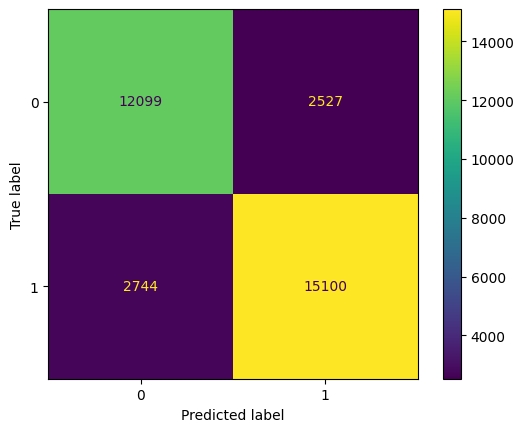

In [77]:
# CONFUSION MATRIX
cm = confusion_matrix(y_test, predictions, labels=the_pipelined_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=the_pipelined_model.classes_)
disp.plot()

plt.show()

In [78]:
y_test.value_counts()

target_satisfaction
1    17844
0    14626
Name: count, dtype: int64

In [79]:
np.unique(predictions, return_counts=True)

(array([0, 1]), array([14843, 17627]))

* accuracy = % correct predictions
* recall(class 1) = among the "1", how many were captured by the model?
* recall(class 0) = among the "0", how many were captured by the model?
* precision(class 1) = among the "predicted 1", how many are truly "1?
* precision(class 0) = among the "predicted 0", how many are truly "0?

In [80]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.82      0.83      0.82     14626
           1       0.86      0.85      0.85     17844

    accuracy                           0.84     32470
   macro avg       0.84      0.84      0.84     32470
weighted avg       0.84      0.84      0.84     32470



#### Trying all the classifiers! [MONDAY 22 AND TUESDAY 23 - JUNE 2026]

❓ I am suggesting your some models to try. Feel free to add more!

In [89]:
# pipelined_svc = make_pipeline(
#     preprocessor,
#     SVC(kernel="rbf")
# )

pipelined_svc = Pipeline([
    ("preproc_davy",preprocessor),
    ("mysupermodel",SVC(kernel="rbf"))
])

pipelined_svc

Pipeline(steps=[('preproc_davy',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num_transformation_davyyyyyy',
                                                  Pipeline(steps=[('num_imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scalers',
                                                                   ColumnTransformer(remainder='passthrough',
                                                                                     transformers=[('std',
                                                                                                    StandardScaler(),
                                                                                                    ['Age']),
                                                                                                   ('rob',
                                                                                                    RobustScaler(),
                                                                                                    ['Flight '
                                                                                                     'Distance']),
                                                                                                   ('minmax',
                                                                                                    MinMaxScale...
                                                                                                     'Type '
                                                                                                     'of '
                                                                                                     'Travel']),
                                                                                                   ('ordinal',
                                                                                                    OrdinalEncoder(categories=[['disloyal '
                                                                                                                                'Customer',
                                                                                                                                'Loyal '
                                                                                                                                'Customer'],
                                                                                                                               ['Eco',
                                                                                                                                'Eco '
                                                                                                                                'Plus',
                                                                                                                                'Business']],
                                                                                                                   dtype=<class 'numpy.int64'>,
                                                                                                                   handle_unknown='use_encoded_value',
                                                                                                                   unknown_value=-1),
                                                                                                    ['Customer '
                                                                                                     'Type',
                                                                                                     'Class'])]))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x159494e30>

In [85]:
pipelined_svc.fit(X_train, y_train)
pipelined_svc.score(X_test, y_test)

0.9333846627656298

In [86]:
# kernel
# poly --> degree
# rbf --> coeff0
# C

In [87]:
my_model = SVC()
my_model.get_params()

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': False,
 'random_state': None,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [93]:
pipelined_svc.get_params()["steps"][1][1]

SVC()

In [96]:
pipelined_svc

Pipeline(steps=[('preproc_davy',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num_transformation_davyyyyyy',
                                                  Pipeline(steps=[('num_imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scalers',
                                                                   ColumnTransformer(remainder='passthrough',
                                                                                     transformers=[('std',
                                                                                                    StandardScaler(),
                                                                                                    ['Age']),
                                                                                                   ('rob',
                                                                                                    RobustScaler(),
                                                                                                    ['Flight '
                                                                                                     'Distance']),
                                                                                                   ('minmax',
                                                                                                    MinMaxScale...
                                                                                                     'Type '
                                                                                                     'of '
                                                                                                     'Travel']),
                                                                                                   ('ordinal',
                                                                                                    OrdinalEncoder(categories=[['disloyal '
                                                                                                                                'Customer',
                                                                                                                                'Loyal '
                                                                                                                                'Customer'],
                                                                                                                               ['Eco',
                                                                                                                                'Eco '
                                                                                                                                'Plus',
                                                                                                                                'Business']],
                                                                                                                   dtype=<class 'numpy.int64'>,
                                                                                                                   handle_unknown='use_encoded_value',
                                                                                                                   unknown_value=-1),
                                                                                                    ['Customer '
                                                                                                     'Type',
                                                                                                     'Class'])]))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x159494e30>

In [ ]:
my_grid = {
    "preproc_davy__num_transformation_davyyyyyy__strategy": ["mean", "median"],
    "mysupermodel__kernel" : ["linear", "poly", "rbf"]
}

In [81]:
models = [LogisticRegression(max_iter=300),
         SGDClassifier(),
         KNeighborsClassifier(), # Should potentially cluster passengers in groups
         SVC(kernel="rbf"),
         #DecisionTreeClassifier(),
         #RandomForestClassifier(),
         #AdaBoostClassifier(),
         #GradientBoostingClassifier()
         ]

In [82]:
models_names = ["linear_classifier",
                "sgd_classifier",
                "kneighbors_classifier",
                "SVC_rbf",
                # "decision_tree_classifier",
                # "random_forest_classifier",
                # "ada_boost_classifier",
                # "gradient_boosting_classifier"
]

❓ For each model, 

1. Chain it to your preprocessor
2. Cross-validate the pipelined model
3. Save the accuracy, the precision and the recall of the pipelined model

In [83]:
%%time
list_of_accuracies = []
list_of_precisions = []
list_of_recalls = []

for model in models:
    None

CPU times: user 7 μs, sys: 45 μs, total: 52 μs
Wall time: 5.72 μs


❓ Create a DataFrame with `model_name`, `accuracy`, `precision`, `recall`. What is your best model?

#### Hypertuning the best model

❓ Finetune your **best model** with `RandomizedSearchCV`

*Feel free to uncomment this cell to try some hyperparameters.*

#### Confusion Matrix

❓ Extract the `best_estimator_` from your previous `RandomizedSearchCV` into a `tuned_forest` variable. Do you need to retrain it ?

❓ What are the `accuracy`, `recall` and `precision` for the `tuned_forest` model?

❓ Plot the confusion matrix of this model for the test set.